# Ejemplo de uso: SSP Q-Learning

Este notebook ilustra el uso del módulo `RLib` para resolver el **Stochastic Shortest Path Problem (SSP)** mediante Q-Learning y para entrenar agentes en un **laberinto**.

Contiene dos partes:
1. **SSP en grafo perceptrón** — grafo sintético con estructura de red neuronal, múltiples selectores de acción y comparación contra la solución óptima (Q*).
2. **Q-Learning en laberinto** — laberinto 2D generado aleatoriamente, entrenamiento y visualización del mejor camino.

---
> Asegúrate de tener instaladas las dependencias:
> ```bash
> !pip install -r ../requirements.txt
> ```

In [1]:
import sys
import os

# Añadir la raíz del proyecto al path
sys.path.insert(0, os.path.abspath(".."))

---
## Parte 1: SSP en Grafo Perceptrón

Resolvemos el problema del camino más corto estocástico sobre un grafo sintético con estructura de perceptrón multicapa. Comparamos las estrategias **ε-greedy**, **UCB1** y **Boltzmann** con la solución óptima obtenida por Dijkstra.

### 1.1 Crear el grafo

In [2]:
from RLib.graphs.perceptron import create_perceptron_graph, plot_network_graph

# Grafo con 4 capas: 1 → 5 → 5 → 1 nodo
# Los arcos tienen longitudes aleatorias entre 100 y 2000 metros
graph = create_perceptron_graph(
    nodes_by_layer=[1, 5, 5, 1],
    min_length=100,
    max_length=2000,
    seed=42,
)

origin_node = 1   # nodo de entrada
target_node = 0   # nodo de salida (renombrado a 0)

print(f"Grafo creado: {graph.number_of_nodes()} nodos, {graph.number_of_edges()} arcos")
print(f"Origen: {origin_node}  |  Destino: {target_node}")

Grafo creado: 12 nodos, 35 arcos
Origen: 1  |  Destino: 0


In [3]:
# Visualizar el grafo con las longitudes de los arcos
plot_network_graph(graph, use_annotations=True, label_pos=0.85)

### 1.2 Calcular la solución óptima con Dijkstra

Usamos el algoritmo de Dijkstra (operando sobre el **grafo invertido** desde el nodo destino) para obtener:
- La **política óptima** π\* — la mejor acción en cada nodo.
- La **tabla Q\*** — el valor óptimo Q\*(s,a) para cada par estado-acción.
- El **camino más corto** (esperado) entre origen y destino.

In [4]:
from RLib.utils.dijkstra import (
    get_optimal_policy_and_q_star,
    get_shortest_path_from_policy,
    get_q_table_for_path,
)

costs_distribution = "uniform"  # distribución de costos para el entrenamiento

# Calcular política óptima y tabla Q*
optimal_policy, q_star = get_optimal_policy_and_q_star(
    graph, target_node, distribution=costs_distribution
)

# Obtener el camino más corto a partir de la política
shortest_path = get_shortest_path_from_policy(optimal_policy, origin_node, target_node)

# Tabla Q* restringida a los nodos del camino más corto (usada para medir error local)
q_star_sp = get_q_table_for_path(q_star, shortest_path)

import numpy as np
optimal_cost = max(q_star[origin_node].values())
print(f"Camino más corto: {shortest_path}")
print(f"Costo óptimo esperado (Q*(s0)): {-optimal_cost:.2f} s")

Calculando tabla Q y política óptima: 100%|██████████| 12/12 [00:00<00:00, 12078.63it/s]

Camino más corto: [1, 4, 9, 0]
Costo óptimo esperado (Q*(s0)): 125.45 s


### 1.3 Crear el entorno

`SSPEnv` envuelve el grafo y gestiona la interacción episodio a episodio: reinicio del estado, selección de acciones posibles y muestreo del costo estocástico del arco.

In [5]:
from RLib.environments.ssp import SSPEnv

def make_env():
    """Crea una instancia fresca del entorno."""
    return SSPEnv(
        graph=graph,
        start_state=origin_node,
        terminal_state=target_node,
        costs_distribution=costs_distribution,
        shortest_path=shortest_path,
    )

env_demo = make_env()
print(env_demo)
print(f"Acciones disponibles desde el nodo {origin_node}: {env_demo.action_set(origin_node)}")

EnvShortestPath DiGraph with 12 nodes and 36 edges
Acciones disponibles desde el nodo 1: [2, 3, 4, 5, 6]


### 1.4 Entrenar agentes con distintas estrategias

Creamos un agente `QAgentSSP` por cada estrategia de selección de acción y los entrenamos de forma secuencial.

In [6]:
from RLib.agents.ssp import QAgentSSP
from RLib.action_selectors import (
    EpsilonGreedyActionSelector,
    EpsilonGreedyDecayActionSelector,
    UCB1ActionSelector,
    BoltzmannSelector,
)

# Tasa de aprendizaje dinámica: decae con el número de visitas a (s,a)
alpha = "1000 / (N(s,a) + 1000)"
num_episodes = 3000

# Definir los selectores a comparar
selectors = [
    EpsilonGreedyActionSelector(epsilon=0.1),
    EpsilonGreedyDecayActionSelector(constant=1.0),
    UCB1ActionSelector(c=1.0),
    BoltzmannSelector(eta="log(n_s) / q_range"),
]

agents = []
for sel in selectors:
    env = make_env()
    agent = QAgentSSP(environment=env, action_selector=sel, alpha=alpha)
    print(f"Entrenando: {agent.strategy} ({sel.get_label()})...")
    agent.train(
        num_episodes=num_episodes,
        shortest_path=shortest_path,
        q_star=q_star,
    )
    agents.append(agent)
    print(f"  ✓ Error final (norma): {agent.results()['max_norm_error'][-1]:.4f}")

Entrenando: ε-greedy (ε = 0.1)...


Episodio 95/3000:   2%|▉                                         | 64/3000 [00:00<00:04, 633.40it/s]

Episodio 0/3000 - Pasos: 4 - Max norm error: 3.550 - Max norm error SP: 1.000


Episodio 103/3000:   2%|▊                                        | 64/3000 [00:00<00:04, 633.40it/s]

Episodio 100/3000 - Pasos: 4 - Max norm error: 2.712 - Max norm error SP: 0.069


...

Episodio 2800/3000 - Pasos: 4 - Max norm error: 0.226 - Max norm error SP: 0.033


Episodio 2958/3000:  98%|█████████████████████████████████████▎| 2947/3000 [00:06<00:00, 369.62it/s]

Episodio 2900/3000 - Pasos: 4 - Max norm error: 0.226 - Max norm error SP: 0.008


Episodio 2999/3000: 100%|██████████████████████████████████████| 3000/3000 [00:06<00:00, 458.01it/s]

Episodio 2999/3000 - Pasos: 4 - Max norm error: 0.226 - Max norm error SP: 0.021
  ✓ Error final (norma): 28.2919


### 1.5 Evaluar los resultados

In [7]:
import pandas as pd

rows = []
for agent in agents:
    r = agent.results()
    rows.append({
        "Estrategia": agent.strategy,
        "Parámetro": agent.action_selector.get_label(),
        "Costo óptimo (Q*)": f"{-r['optimal_cost']:.2f} s",
        "Error final ‖Qₜ−Q*‖∞": f"{r['max_norm_error'][-1]:.4f}",
        "Error SP final": f"{r['max_norm_error_shortest_path'][-1]:.4f}",
        "Regret acumulado": f"{r['regret'][-1]:.2f}",
        "Mejor camino": agent.best_path(),
    })

df = pd.DataFrame(rows)
df

,Estrategia,Parámetro,Costo óptimo (Q*),Error final ‖Qₜ−Q*‖∞,Error SP final,Regret acumulado,Mejor camino
0,ε-greedy,ε = 0.1,125.45 s,29.3017,1.0842,93126.41,"[1, 4, 9, 0]"
1,e-decay,c = 1.0,125.45 s,340.1832,0.8576,7126.20,"[1, 4, 9, 0]"
2,UCB1,c = 1.0,125.45 s,380.1196,0.5196,4436.13,"[1, 4, 9, 0]"
3,Boltzmann,η = log(n_s) / q_range,125.45 s,28.2919,2.6002,83388.29,"[1, 4, 9, 0]"


### 1.6 Comparar la convergencia de Q al óptimo Q*

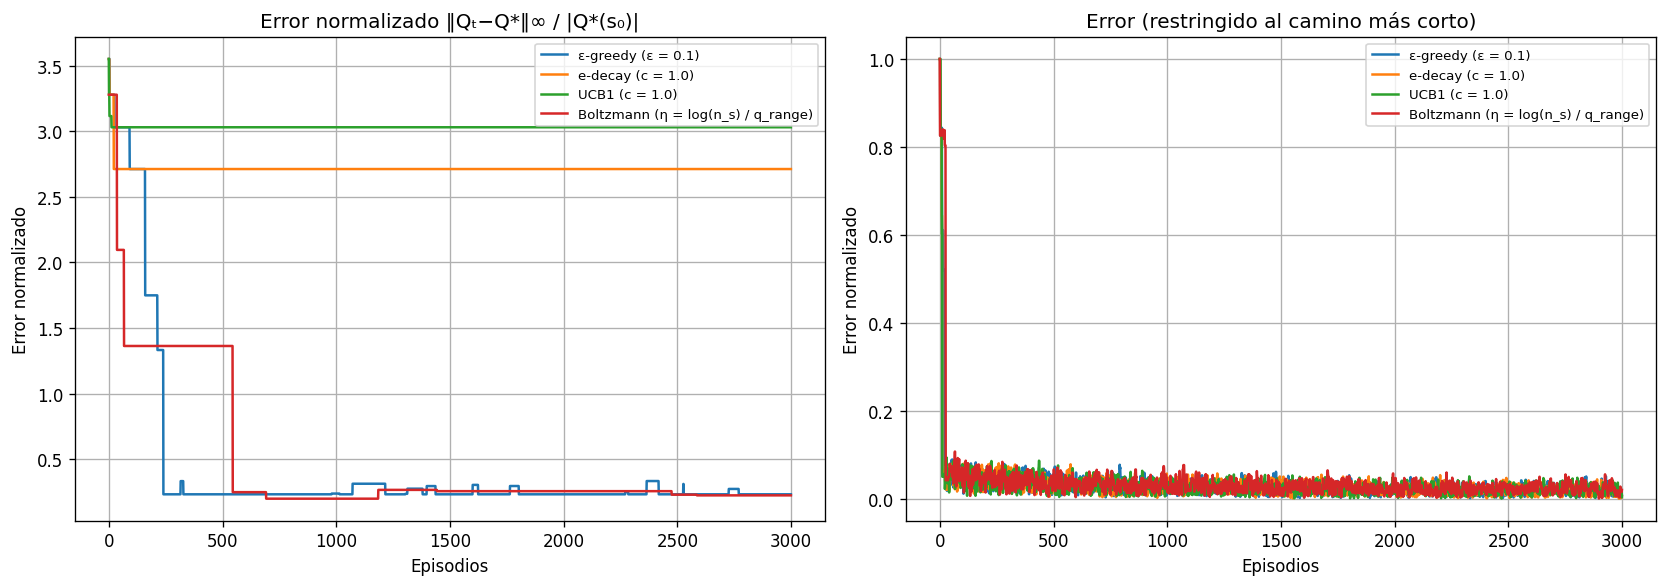

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for agent in agents:
    r = agent.results()
    label = f"{agent.strategy} ({agent.action_selector.get_label()})"
    episodes = list(range(len(r['max_norm_error_normalized'])))
    
    axes[0].plot(episodes, r['max_norm_error_normalized'], label=label)
    axes[1].plot(episodes, r['max_norm_error_shortest_path_normalized'], label=label)

axes[0].set_title("Error normalizado ‖Qₜ−Q*‖∞ / |Q*(s₀)|")
axes[0].set_xlabel("Episodios")
axes[0].set_ylabel("Error normalizado")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_title("Error (restringido al camino más corto)")
axes[1].set_xlabel("Episodios")
axes[1].set_ylabel("Error normalizado")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

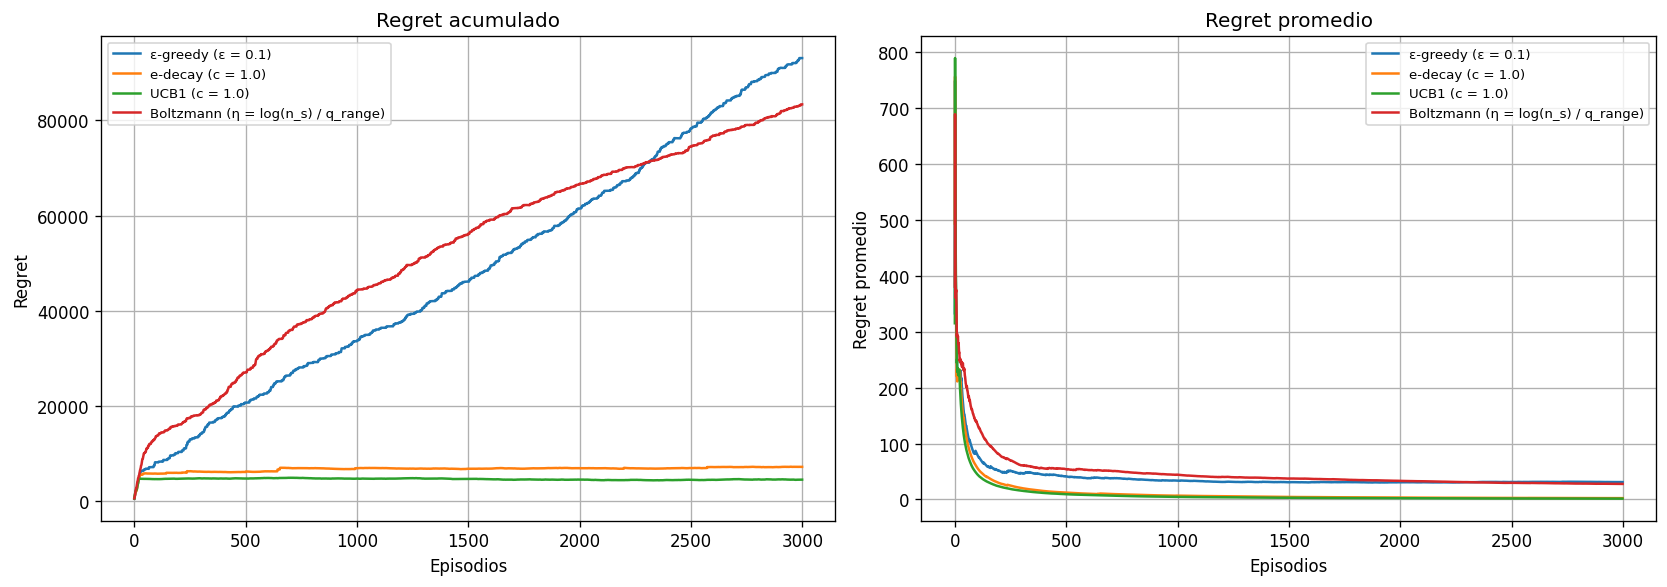

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for agent in agents:
    r = agent.results()
    label = f"{agent.strategy} ({agent.action_selector.get_label()})"
    episodes = list(range(len(r['regret'])))
    
    axes[0].plot(episodes, r['regret'], label=label)
    axes[1].plot(episodes, r['average_regret'], label=label)

axes[0].set_title("Regret acumulado")
axes[0].set_xlabel("Episodios")
axes[0].set_ylabel("Regret")
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_title("Regret promedio")
axes[1].set_xlabel("Episodios")
axes[1].set_ylabel("Regret promedio")
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 1.7 Mejor camino aprendido por cada agente

In [10]:
print(f"Camino óptimo (Dijkstra): {shortest_path}")
print()
for agent in agents:
    label = f"{agent.strategy} ({agent.action_selector.get_label()})"
    path = agent.best_path()
    match = "✓" if path == shortest_path else "✗"
    print(f"{match} {label}")
    print(f"  Camino: {path}")

Camino óptimo (Dijkstra): [1, 4, 9, 0]

✓ ε-greedy (ε = 0.1)
  Camino: [1, 4, 9, 0]
✓ e-decay (c = 1.0)
  Camino: [1, 4, 9, 0]
✓ UCB1 (c = 1.0)
  Camino: [1, 4, 9, 0]
✓ Boltzmann (η = log(n_s) / q_range)
  Camino: [1, 4, 9, 0]


---
## Parte 2: Q-Learning en Laberinto

Entrenamos agentes Q-Learning para resolver un laberinto 2D generado aleatoriamente usando el algoritmo de **recursive backtracking**. Las acciones disponibles son moverse arriba, abajo, izquierda o derecha.

### 2.1 Generar y visualizar el laberinto

Laberinto (16, 16), inicio=(1, 1), meta=(14, 14)


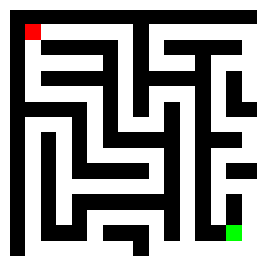

In [11]:
from RLib.environments.maze import Maze, generate_maze, render_maze, dijkstra_validate

# Generar un laberinto de 15×15
rows, cols = 15, 15
maze_array, start, goal = generate_maze(rows, cols)

# Verificar que existe un camino entre inicio y meta
assert dijkstra_validate(maze_array, start, goal), "El laberinto no tiene camino válido"

print(f"Laberinto {maze_array.shape}, inicio={start}, meta={goal}")
render_maze(maze_array, start, goal)

### 2.2 Crear el entorno y los agentes

In [12]:
from RLib.agents.maze import QAgentMaze
from RLib.action_selectors import (
    EpsilonGreedyActionSelector,
    UCB1ActionSelector,
    BoltzmannSelector,
)

alpha_expr = "1000 / (1000 + N(s,a))"

environment = Maze(maze_array, start, goal)

# Crear agentes con distintas estrategias
eps_agent = QAgentMaze(
    environment=environment,
    alpha=alpha_expr,
    action_selector=EpsilonGreedyActionSelector(epsilon=0.1),
)
ucb_agent = QAgentMaze(
    environment=environment,
    alpha=alpha_expr,
    action_selector=UCB1ActionSelector(c=2),
)
boltz_agent = QAgentMaze(
    environment=environment,
    alpha=alpha_expr,
    action_selector=BoltzmannSelector(eta=0.1),
)

maze_agents = [eps_agent, ucb_agent, boltz_agent]
print("Agentes creados:", [a.strategy for a in maze_agents])

Agentes creados: ['ε-greedy', 'UCB1', 'Boltzmann']


### 2.3 Entrenar los agentes

In [13]:
num_episodes_maze = 1500

for agent in maze_agents:
    print(f"Entrenando {agent.strategy}...")
    agent.train(num_episodes=num_episodes_maze)
print("\n✓ Entrenamiento completado")

Entrenando ε-greedy...


Entrenando: 100%|██████████████████████████████████████████████| 1500/1500 [00:02<00:00, 581.30it/s]


Entrenando UCB1...


Entrenando: 100%|██████████████████████████████████████████████| 1500/1500 [00:04<00:00, 365.86it/s]


Entrenando Boltzmann...


Entrenando: 100%|██████████████████████████████████████████████| 1500/1500 [00:05<00:00, 267.57it/s]


✓ Entrenamiento completado


### 2.4 Comparar número de pasos por episodio

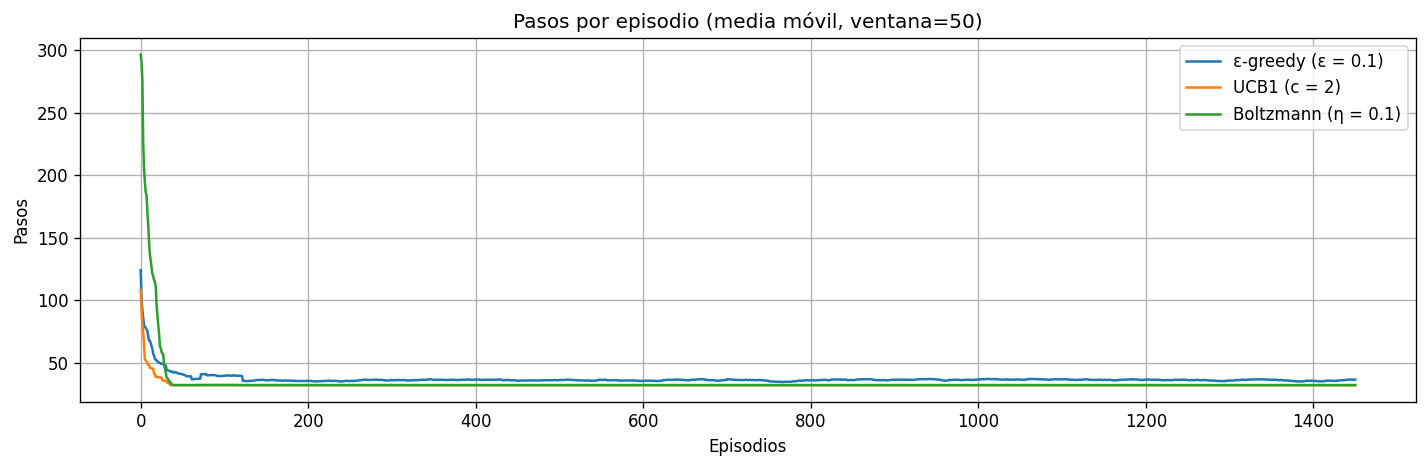

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 4), dpi=120)

window = 50  # ventana de suavizado
for agent in maze_agents:
    steps = agent.steps
    smoothed = np.convolve(steps, np.ones(window) / window, mode='valid')
    label = f"{agent.strategy} ({agent.action_selector.get_label()})"
    ax.plot(smoothed, label=label, linewidth=1.5)

ax.set_title(f"Pasos por episodio (media móvil, ventana={window})")
ax.set_xlabel("Episodios")
ax.set_ylabel("Pasos")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 2.5 Visualizar el mejor camino aprendido

Mejor camino aprendido por el agente ε-greedy:
  33 pasos: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6)]...


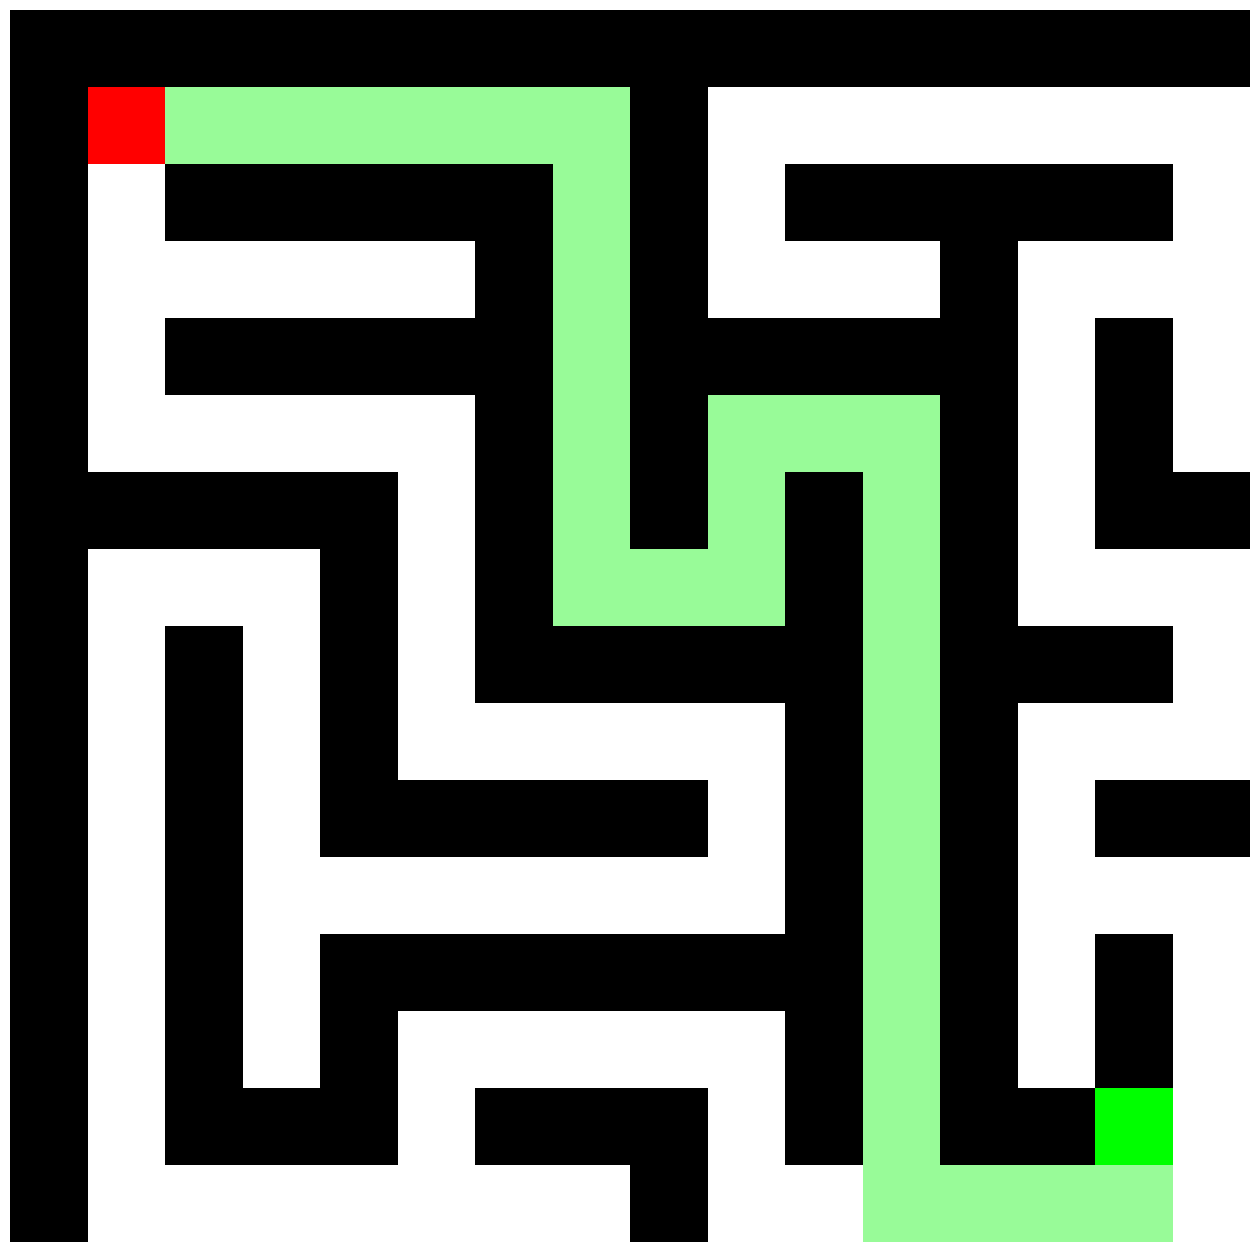

In [15]:
print("Mejor camino aprendido por el agente ε-greedy:")
best_path_indices = eps_agent.best_path(environment.start_state())
best_path_positions = [environment.position(s) for s in best_path_indices]
print(f"  {len(best_path_positions)} pasos: {best_path_positions[:6]}...")

environment.render(path=best_path_positions)

---
## Resumen

| Aspecto | Parte 1 (SSP en grafo) | Parte 2 (Laberinto) |
|---------|----------------------|---------------------|
| Entorno | `SSPEnv` + grafo perceptrón | `Maze` 2D |
| Agente | `QAgentSSP` | `QAgentMaze` |
| Evaluación óptima | Dijkstra → Q* | N/A |
| Métrica principal | ‖Qₜ−Q*‖∞ normalizado | Pasos por episodio |
| Estrategias | ε-greedy, ε-decay, UCB1, Boltzmann | ε-greedy, UCB1, Boltzmann |

### Próximos pasos

- Experimenta cambiando `nodes_by_layer` para grafos más grandes (ver `scripts/perceptron.py`).
- Prueba grafos de ciudades reales descargados con `osmnx` (ver `scripts/santiago.py`).
- Ajusta `alpha`, `num_episodes` o los parámetros de los selectores para observar el efecto en la convergencia.
- Consulta la [documentación en `docs/`](../docs/index.md) para una referencia completa del módulo `RLib`.